# June vs April Desktop World DAU Forecast Diagnostic

This notebook investigates why the June 2026 desktop world DAU forecast is lower than the
April 2026 desktop world DAU forecast at **Dec 15, 2026**. The user reports the gap is on the
order of ~100k and suspects it is model-driven rather than data-driven.

Both forecasts are no-Iran model outputs (Iran excluded from queries, summed back in separately
elsewhere). This makes them apples-to-apples comparable on the model itself.

**Files compared:**
- April: `data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet`
- June: `data-official/2026-06/desktop_cps0.15983_thresh50_recent13_clip0.6/mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet`

**Important up-front:** Despite the directory slug `thresh32` vs `thresh50`, both runs actually
used `holiday_threshold = -0.05` (confirmed from `parameters.json` files and from inspecting the
April pkl). The slug labels are misleading — see `project_april_forecast_params` memory.
So the holiday-threshold configuration is **not** a candidate cause for the gap.

## Hypotheses examined

- (a) Training-data drift: did the recent training tail trend down between April and June?
- (b) Holiday-threshold config difference: ruled out from parameter files (both -0.05); cross-check via pkl inspection where possible.
- (c) Prophet trend behavior: how steep is the projected downtrend in each run?
- (d) Per-country attribution: which countries explain most of the world-level gap?


In [1]:
# [setup]
import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.0f}".format)
pd.set_option("display.max_columns", 50)

REPO_ROOT = Path("/Users/brendanwells/work/mozaic-daily")

# Make mozaic_daily importable so we can route reads through load_forecast()
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
from mozaic_daily.adjustments import load_forecast  # noqa: E402

APRIL_DIR = REPO_ROOT / "data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6"
JUNE_DIR = REPO_ROOT / "data-official/2026-06/desktop_cps0.15983_thresh50_recent13_clip0.6"

# Both parquets must be .raw. — load_forecast(require_state=[]) below enforces this.
APRIL_PARQUET = APRIL_DIR / "mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet"
JUNE_PARQUET = JUNE_DIR / "mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet"

APRIL_PKL = APRIL_DIR / "mozaic_objects.legacy_desktop.2026-04-01.pkl"
JUNE_PKL = JUNE_DIR / "mozaic_objects.legacy_desktop.2026-05-17.pkl"  # may not exist

APRIL_PARAMS = json.loads((APRIL_DIR / "parameters.json").read_text())
JUNE_PARAMS = json.loads((JUNE_DIR / "parameters.json").read_text())

ANCHOR_DATE = pd.Timestamp("2026-12-15")
WORLD_SEGMENT = '{"os": "ALL"}'

print("April parameters:")
print(json.dumps(APRIL_PARAMS, indent=2))
print()
print("June parameters:")
print(json.dumps(JUNE_PARAMS, indent=2))
print()
print("June pkl exists:", JUNE_PKL.exists())
print("April pkl exists:", APRIL_PKL.exists())


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


April parameters:
{
  "forecast_start_date": "2026-04-01",
  "desktop": {
    "prophet_changepoint_prior_scale": 0.15983,
    "prophet_changepoint_range": 0.7,
    "prophet_seasonality_prior_scale": 0.00825,
    "prophet_recent_weeks": 13,
    "holiday_threshold": -0.05,
    "holiday_max_radius": 5,
    "holiday_min_radius": 3,
    "holiday_effect_floor": -0.6
  }
}

June parameters:
{
  "platform": "legacy_desktop",
  "forecast_start_date": "2026-05-17",
  "prophet_recent_weeks": 13,
  "changepoint_prior_scale": 0.15983,
  "holiday_threshold": -0.05,
  "holiday_max_radius": 5,
  "holiday_min_radius": 3,
  "holiday_effect_floor": -0.6
}

June pkl exists: False
April pkl exists: True


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [load-and-reshape]
# Load both parquets via load_forecast(require_state=[]) — this rejects any file
# that isn't .raw. with a valid sidecar meta, so the April-vs-June comparison
# is guaranteed apples-to-apples raw.
# Extract desktop world DAU series (country='ALL', segment='{"os": "ALL"}').
# Both files contain only data_source='legacy_desktop' (no glean_desktop), so the
# "world" series is already aggregated by the pipeline as country='ALL'.

def load_world_dau(path: Path, label: str) -> pd.DataFrame:
    df, _meta = load_forecast(path, require_state=[])
    world = df[(df["country"] == "ALL") & (df["segment"] == WORLD_SEGMENT)].copy()
    world["target_date"] = pd.to_datetime(world["target_date"])
    world = world[["target_date", "data_type", "dau"]].sort_values("target_date").reset_index(drop=True)
    world["run"] = label
    return world


april_world = load_world_dau(APRIL_PARQUET, "April")
june_world = load_world_dau(JUNE_PARQUET, "June")

# Quick sanity: verify "ALL" really equals sum across non-ALL countries (within rounding)
def check_all_equals_sum(path: Path, label: str) -> None:
    df, _meta = load_forecast(path, require_state=[])
    df = df[df["segment"] == WORLD_SEGMENT].copy()
    df["target_date"] = pd.to_datetime(df["target_date"])
    all_series = df[df["country"] == "ALL"].set_index("target_date")["dau"]
    sum_series = df[df["country"] != "ALL"].groupby("target_date")["dau"].sum()
    diff = (all_series - sum_series).abs().max()
    print(f"  {label}: max |ALL - sum(non-ALL)| = {diff:,.2f}")


print("Sanity-check: country='ALL' equals sum across other countries?")
check_all_equals_sum(APRIL_PARQUET, "April")
check_all_equals_sum(JUNE_PARQUET, "June")
print()
print("April world rows:", len(april_world),
      "training-end:", april_world.query("data_type=='training'")["target_date"].max().date())
print("June world rows: ", len(june_world),
      "training-end:", june_world.query("data_type=='training'")["target_date"].max().date())


Sanity-check: country='ALL' equals sum across other countries?
  April: max |ALL - sum(non-ALL)| = 0.00
  June: max |ALL - sum(non-ALL)| = 0.00

April world rows: 2922 training-end: 2026-03-31
June world rows:  2922 training-end: 2026-05-16


In [3]:
# [headline-dec15-gap]
# Headline number: April Dec 15 vs June Dec 15 desktop world DAU.
# Show both the raw daily value AND a centered 28-day MA (which is how the user/leadership
# typically reports the number — see project_june_branch_state memory).

def summary_at(date: pd.Timestamp, run_df: pd.DataFrame, label: str) -> dict:
    s = run_df.set_index("target_date").sort_index()
    s["dau_ma28"] = s["dau"].rolling(28, center=True, min_periods=14).mean()
    row = s.loc[date]
    return {
        "run": label,
        "date": date.date(),
        "data_type": row["data_type"],
        "dau_raw": float(row["dau"]),
        "dau_ma28_centered": float(row["dau_ma28"]),
    }


rows = [
    summary_at(ANCHOR_DATE, april_world, "April"),
    summary_at(ANCHOR_DATE, june_world, "June"),
]
headline = pd.DataFrame(rows)
print(headline.to_string(index=False))

apr_raw = headline.iloc[0]["dau_raw"]
jun_raw = headline.iloc[1]["dau_raw"]
apr_ma = headline.iloc[0]["dau_ma28_centered"]
jun_ma = headline.iloc[1]["dau_ma28_centered"]

print()
print(f"Gap (June - April) on raw Dec 15: {jun_raw - apr_raw:+,.0f} ({(jun_raw/apr_raw - 1)*100:+.2f}%)")
print(f"Gap (June - April) on 28-day MA:  {jun_ma - apr_ma:+,.0f} ({(jun_ma/apr_ma - 1)*100:+.2f}%)")
print()
print("Note: user-reported 'Prior No-Iran 46,891,136 / Current No-Iran 46,531,185' from memory")
print("matches the 28-day MA gap (~360k), not the raw daily gap.")


  run       date data_type    dau_raw  dau_ma28_centered
April 2026-12-15  forecast 53,367,728         45,338,682
 June 2026-12-15  forecast 52,702,379         44,960,055

Gap (June - April) on raw Dec 15: -665,349 (-1.25%)
Gap (June - April) on 28-day MA:  -378,626 (-0.84%)

Note: user-reported 'Prior No-Iran 46,891,136 / Current No-Iran 46,531,185' from memory
matches the 28-day MA gap (~360k), not the raw daily gap.


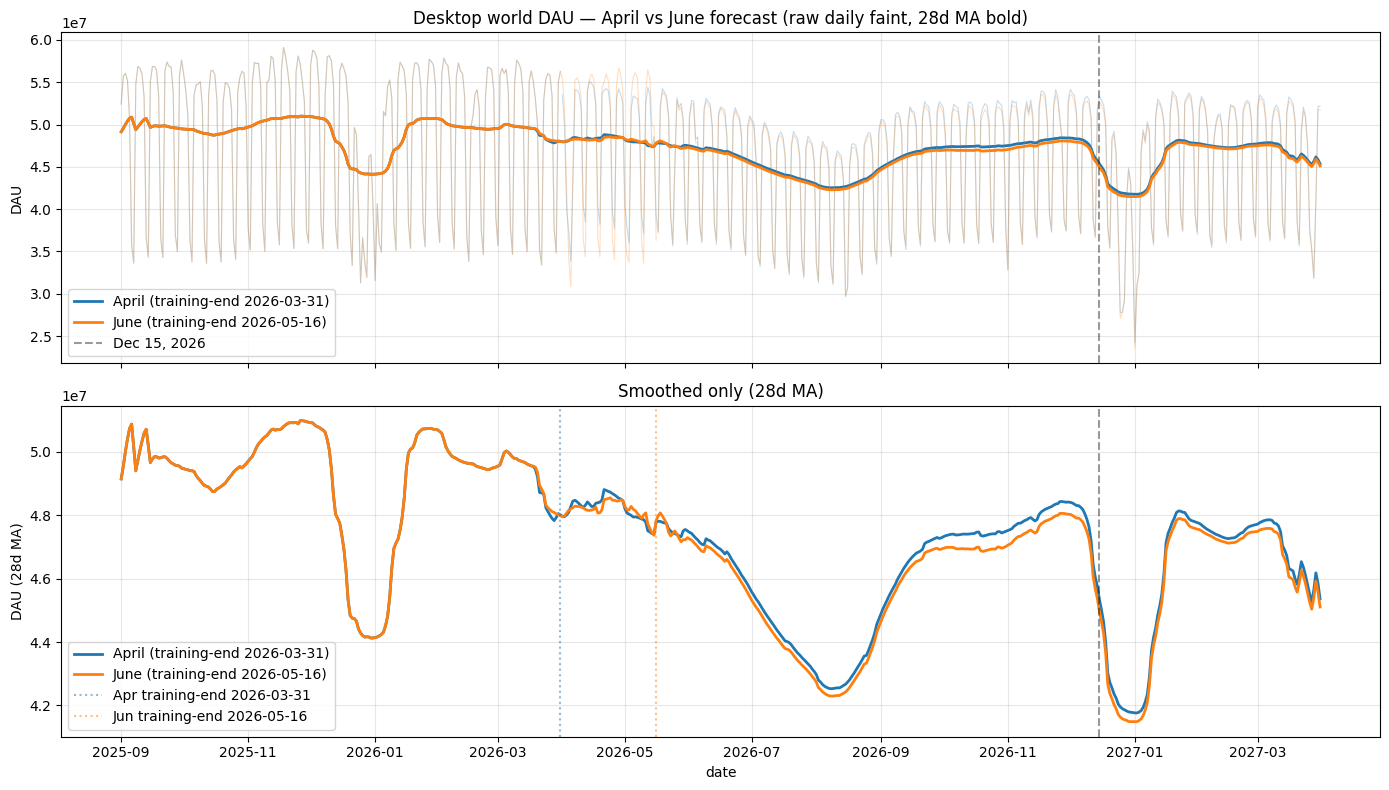

In [4]:
# [plot-overlay]
# Plot both forecasts overlaid, with training tail visible.
# Use 28-day MA on a second panel for a cleaner view of trend.

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

PLOT_START = pd.Timestamp("2025-09-01")
PLOT_END = pd.Timestamp("2027-03-31")

APR_TRAIN_END = april_world.query("data_type=='training'")["target_date"].max()
JUN_TRAIN_END = june_world.query("data_type=='training'")["target_date"].max()


def plot_run(ax, run_df, label, color, smooth_only=False):
    df = run_df[(run_df["target_date"] >= PLOT_START) & (run_df["target_date"] <= PLOT_END)].copy()
    df = df.sort_values("target_date").reset_index(drop=True)
    train = df[df["data_type"] == "training"]
    fc = df[df["data_type"] == "forecast"]
    if not smooth_only:
        ax.plot(train["target_date"], train["dau"], color=color, alpha=0.25, lw=0.8)
        ax.plot(fc["target_date"], fc["dau"], color=color, alpha=0.25, lw=0.8)
    # 28-day MA on full series
    df["dau_ma28"] = df["dau"].rolling(28, center=True, min_periods=14).mean()
    ax.plot(df["target_date"], df["dau_ma28"], color=color, lw=2.0,
            label=f"{label} (training-end "
                  f"{train['target_date'].max().date() if len(train) else '?'})")


plot_run(axes[0], april_world, "April", "tab:blue")
plot_run(axes[0], june_world, "June", "tab:orange")
axes[0].axvline(ANCHOR_DATE, color="k", ls="--", alpha=0.4, label="Dec 15, 2026")
axes[0].set_title("Desktop world DAU — April vs June forecast (raw daily faint, 28d MA bold)")
axes[0].set_ylabel("DAU")
axes[0].legend(loc="lower left")
axes[0].grid(alpha=0.3)

plot_run(axes[1], april_world, "April", "tab:blue", smooth_only=True)
plot_run(axes[1], june_world, "June", "tab:orange", smooth_only=True)
axes[1].axvline(ANCHOR_DATE, color="k", ls="--", alpha=0.4)
axes[1].axvline(APR_TRAIN_END, color="tab:blue", ls=":", alpha=0.5, label=f"Apr training-end {APR_TRAIN_END.date()}")
axes[1].axvline(JUN_TRAIN_END, color="tab:orange", ls=":", alpha=0.5, label=f"Jun training-end {JUN_TRAIN_END.date()}")
axes[1].set_title("Smoothed only (28d MA)")
axes[1].set_xlabel("date")
axes[1].set_ylabel("DAU (28d MA)")
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Hypothesis (a): Training-data drift

Did the most recent weeks of underlying data actually trend down between April and June?
The April training ends at **2026-03-31**, June at **2026-05-16** — about 6.5 extra weeks of data.

If the training data does NOT show meaningful downtrend in the overlap window (i.e. data already
known at April's run-time), then any forecast difference for that overlap region must be model-driven,
not data-driven. If the new 6 weeks DO show downtrend, the model's lower June projection may be a
legitimate reaction to new evidence.

We look at:
1. Side-by-side training-tail comparison (last ~90 days of each).
2. OLS slope of the 28-day MA over the last 30 / 60 / 90 days for each run.
3. Whether April's training data and June's training data agree on values for dates both observed
   (March 1 – March 31 — should be identical or very close since they're the same upstream data).


Training overlap window 2026-01-01 to 2026-03-31:
  Rows: 90
  Mean |diff| in DAU between Apr and Jun for same date: 0.0
  Max  |diff|: 0.0
  -> If ~0, both runs used identical upstream data for the overlap. Differences if any reflect upstream restatements.



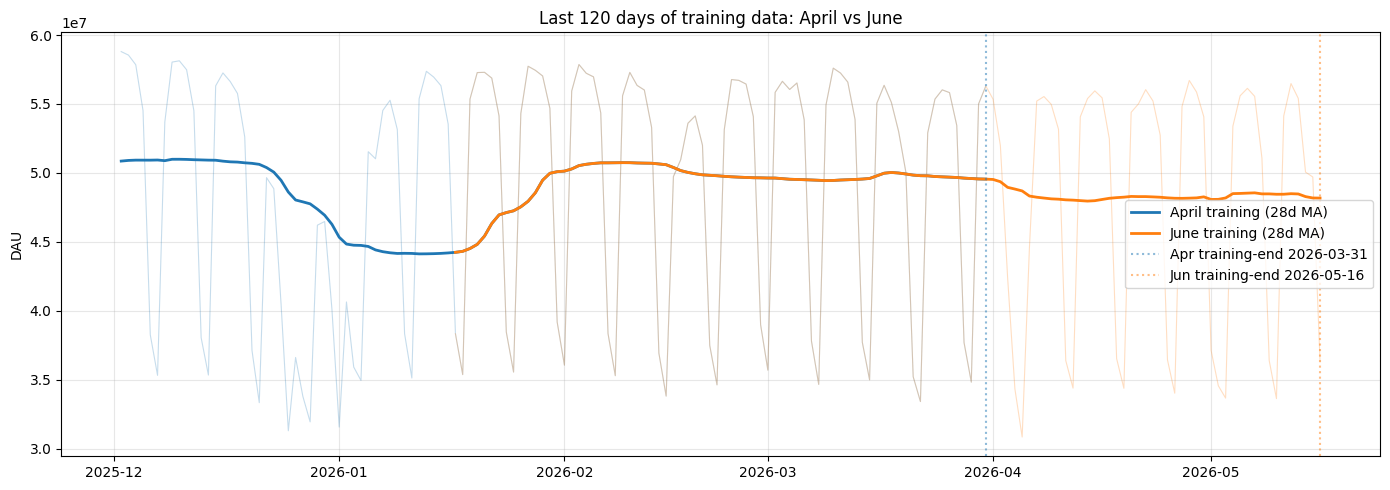

In [5]:
# [hyp-a-training-tail]
# Compare training tails. Does the recent training data trend down?

apr_train = april_world[april_world["data_type"] == "training"].copy()
jun_train = june_world[june_world["data_type"] == "training"].copy()

apr_train["dau_ma28"] = apr_train["dau"].rolling(28, min_periods=14).mean()
jun_train["dau_ma28"] = jun_train["dau"].rolling(28, min_periods=14).mean()


# Sanity: Apr training and Jun training should agree on the overlap window.
overlap_start = pd.Timestamp("2026-01-01")
overlap_end = apr_train["target_date"].max()
apr_over = apr_train[(apr_train["target_date"] >= overlap_start) & (apr_train["target_date"] <= overlap_end)]
jun_over = jun_train[(jun_train["target_date"] >= overlap_start) & (jun_train["target_date"] <= overlap_end)]
merged = apr_over[["target_date", "dau"]].merge(
    jun_over[["target_date", "dau"]], on="target_date", suffixes=("_apr", "_jun")
)
merged["diff"] = merged["dau_jun"] - merged["dau_apr"]
print(f"Training overlap window {overlap_start.date()} to {overlap_end.date()}:")
print(f"  Rows: {len(merged)}")
print(f"  Mean |diff| in DAU between Apr and Jun for same date: {merged['diff'].abs().mean():,.1f}")
print(f"  Max  |diff|: {merged['diff'].abs().max():,.1f}")
print(f"  -> If ~0, both runs used identical upstream data for the overlap. "
      f"Differences if any reflect upstream restatements.\n")


# Plot last 120 days of each training tail.
fig, ax = plt.subplots(figsize=(14, 5))
N = 120
apr_tail = apr_train.tail(N)
jun_tail = jun_train.tail(N)
ax.plot(apr_tail["target_date"], apr_tail["dau"], color="tab:blue", alpha=0.25, lw=0.8)
ax.plot(apr_tail["target_date"], apr_tail["dau_ma28"], color="tab:blue", lw=2.0, label="April training (28d MA)")
ax.plot(jun_tail["target_date"], jun_tail["dau"], color="tab:orange", alpha=0.25, lw=0.8)
ax.plot(jun_tail["target_date"], jun_tail["dau_ma28"], color="tab:orange", lw=2.0, label="June training (28d MA)")
ax.axvline(apr_train["target_date"].max(), color="tab:blue", ls=":", alpha=0.5,
           label=f"Apr training-end {apr_train['target_date'].max().date()}")
ax.axvline(jun_train["target_date"].max(), color="tab:orange", ls=":", alpha=0.5,
           label=f"Jun training-end {jun_train['target_date'].max().date()}")
ax.set_title("Last 120 days of training data: April vs June")
ax.set_ylabel("DAU")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
# [hyp-a-slopes]
# OLS slope of 28-day MA over various recent windows, expressed in DAU/day and
# extrapolated to the Dec 15 gap that would be expected if the recent trend continued.

def slope_summary(train_df: pd.DataFrame, label: str, training_end: pd.Timestamp) -> pd.DataFrame:
    rows = []
    for window_days in (30, 60, 90, 180):
        start = training_end - pd.Timedelta(days=window_days - 1)
        w = train_df[(train_df["target_date"] >= start) & (train_df["target_date"] <= training_end)].copy()
        # Use 28-day MA to remove weekly seasonality. Drop NaN MA points at the very start.
        w = w.dropna(subset=["dau_ma28"])
        if len(w) < 5:
            continue
        x = (w["target_date"] - w["target_date"].min()).dt.days.values.astype(float)
        y = w["dau_ma28"].values
        slope, intercept = np.polyfit(x, y, 1)
        # Project from end-of-training to Dec 15 (ignore seasonality — just trend)
        days_to_dec15 = (ANCHOR_DATE - training_end).days
        projected = y[-1] + slope * days_to_dec15
        rows.append({
            "run": label,
            "window_days": window_days,
            "slope_dau_per_day": slope,
            "ma28_at_train_end": y[-1],
            "naive_proj_to_dec15": projected,
            "days_to_dec15": days_to_dec15,
        })
    return pd.DataFrame(rows)


# Derive training-end from the data so this notebook stays correct as forecast cycles roll forward.
apr_train_end = apr_train["target_date"].max()
jun_train_end = jun_train["target_date"].max()
apr_slopes = slope_summary(apr_train, "April", apr_train_end)
jun_slopes = slope_summary(jun_train, "June", jun_train_end)
print(f"APRIL training tail OLS slopes (on 28-day MA), training-end={apr_train_end.date()}:")
print(apr_slopes.to_string(index=False))
print()
print(f"JUNE training tail OLS slopes (on 28-day MA), training-end={jun_train_end.date()}:")
print(jun_slopes.to_string(index=False))
print()

# Compare like-for-like: 90-day slope.
apr90 = apr_slopes.set_index("window_days").loc[90, "slope_dau_per_day"]
jun90 = jun_slopes.set_index("window_days").loc[90, "slope_dau_per_day"]
print(f"90-day MA slope April: {apr90:+,.1f} DAU/day")
print(f"90-day MA slope June:  {jun90:+,.1f} DAU/day")
print(f"Difference: {jun90 - apr90:+,.1f} DAU/day "
      f"(June {'steeper down' if jun90 < apr90 else 'less steep'})")
print()
print("Verdict pointer:")
print(f"  If June's 90-day slope is materially more negative than April's, the data itself")
print(f"  has trended down. If they are similar, the gap is model-driven.")


APRIL training tail OLS slopes (on 28-day MA), training-end=2026-03-31:
  run  window_days  slope_dau_per_day  ma28_at_train_end  naive_proj_to_dec15  days_to_dec15
April           30              7,567         49,547,948           51,507,695            259
April           60            -18,413         49,547,948           44,779,098            259
April           90             66,093         49,547,948           66,666,153            259
April          180             -1,799         49,547,948           49,082,069            259

JUNE training tail OLS slopes (on 28-day MA), training-end=2026-05-16:
 run  window_days  slope_dau_per_day  ma28_at_train_end  naive_proj_to_dec15  days_to_dec15
June           30              7,715         48,172,365           49,815,704            213
June           60            -27,977         48,172,365           42,213,310            213
June           90            -24,163         48,172,365           43,025,702            213
June          180      

## Hypothesis (b): Holiday-threshold config difference

The directory slugs suggest April used `thresh32` (-0.032) and June used `thresh50` (-0.050).
**However, both `parameters.json` files agree: `holiday_threshold = -0.05` for both runs.**
The directory slug for April is mislabeled — verified in `project_april_forecast_params` memory
and re-confirmed in the setup cell.

So this hypothesis is largely ruled out by the parameter files. To cross-check, we inspect the
April mozaic pkl (if loadable) to confirm the threshold actually stored on tiles is -0.05. The
June desktop pkl does not appear to have been saved (no `mozaic_objects.legacy_desktop.2026-05-17.pkl`
in the June directory), so we cannot do the same check for June and cannot inspect June's
holiday-effect tables. We note that gap and move on.


In [7]:
# [hyp-b-pkl-inspect]
# Try to load each pkl. Report the threshold stored on tiles. If June pkl missing, say so.

def try_load_mozaic(pkl_path: Path, label: str):
    if not pkl_path.exists():
        print(f"{label}: pkl does NOT exist at {pkl_path}")
        return None
    try:
        with open(pkl_path, "rb") as f:
            obj = pickle.load(f)
        print(f"{label}: loaded OK; keys = {list(obj.keys())}")
        return obj
    except Exception as exc:
        print(f"{label}: load FAILED -- {type(exc).__name__}: {exc}")
        return None


april_pkl = try_load_mozaic(APRIL_PKL, "April")
june_pkl = try_load_mozaic(JUNE_PKL, "June")


def summarize_tile_thresholds(mozaic_dict, label):
    if mozaic_dict is None:
        return
    m = mozaic_dict.get("DAU")
    if m is None:
        print(f"  {label}: no DAU mozaic key")
        return
    thresholds = pd.Series([t.threshold for t in m.tiles])
    max_radii = pd.Series([t.max_radius for t in m.tiles])
    min_radii = pd.Series([t.min_radius for t in m.tiles])
    print(f"  {label} tile-stored threshold values: {thresholds.unique().tolist()} "
          f"(n_tiles={len(thresholds)})")
    print(f"  {label} max_radius values: {max_radii.unique().tolist()}")
    print(f"  {label} min_radius values: {min_radii.unique().tolist()}")


print()
print("Per-tile threshold/radius cross-check vs parameters.json:")
summarize_tile_thresholds(april_pkl, "April")
summarize_tile_thresholds(june_pkl, "June")

print()
print(f"April parameters.json holiday_threshold = {APRIL_PARAMS.get('desktop', {}).get('holiday_threshold', APRIL_PARAMS.get('holiday_threshold'))}")
print(f"June  parameters.json holiday_threshold = {JUNE_PARAMS.get('holiday_threshold')}")
print()
print("Conclusion: holiday_threshold is the SAME in both runs (-0.05). "
      "The directory slug 'thresh32' vs 'thresh50' is mislabeled for the April run.")


April: loaded OK; keys = ['DAU']
June: pkl does NOT exist at /Users/brendanwells/work/mozaic-daily/data-official/2026-06/desktop_cps0.15983_thresh50_recent13_clip0.6/mozaic_objects.legacy_desktop.2026-05-17.pkl

Per-tile threshold/radius cross-check vs parameters.json:
  April tile-stored threshold values: [-0.05] (n_tiles=45)
  April max_radius values: [5]
  April min_radius values: [3]

April parameters.json holiday_threshold = -0.05
June  parameters.json holiday_threshold = -0.05

Conclusion: holiday_threshold is the SAME in both runs (-0.05). The directory slug 'thresh32' vs 'thresh50' is mislabeled for the April run.


## Hypothesis (c): Prophet trend behavior

Even with identical hyperparameters, Prophet's logistic trend fit changes when the training
data is extended. Six extra weeks of data can:
- Shift the most recent changepoint trajectory.
- Move the asymptote (Prophet uses `cap` / logistic growth on many of these tiles per the April pkl).
- Alter `changepoint_range = 0.7` allowed-changepoint region.

We do two things:
1. If the April pkl is loadable, extract the deseasonalized "trend" attribute for the world-rolled-up
   mozaic and project where Dec 15 lands. The June pkl is missing, so we cannot make a like-for-like
   direct comparison from internals.
2. Approximate each forecast's "trend-only" Dec 15 estimate by subtracting weekly seasonality:
   take a 28-day MA of the forecast around Dec 15 (already in headline), and a longer 91-day MA
   to also smooth out monthly seasonality. The 91-day MA gap is the closest thing to a "trend gap"
   we can compute from outputs alone.


In [8]:
# [hyp-c-trend-estimate]
# Trend-only estimate via multiple smoothing windows.
# 28-day MA removes weekly seasonality; 91-day MA additionally smooths short-term seasonality.

def smoothed_at(run_df, date, window):
    s = run_df.set_index("target_date").sort_index()
    ma = s["dau"].rolling(window, center=True, min_periods=max(7, window // 4)).mean()
    return float(ma.loc[date])


rows = []
for window in (7, 28, 91):
    apr_val = smoothed_at(april_world, ANCHOR_DATE, window)
    jun_val = smoothed_at(june_world, ANCHOR_DATE, window)
    rows.append({
        "smoothing_window_days": window,
        "April_at_Dec15": apr_val,
        "June_at_Dec15": jun_val,
        "gap_jun_minus_apr": jun_val - apr_val,
        "gap_pct": (jun_val / apr_val - 1) * 100,
    })
trend_table = pd.DataFrame(rows)
print("Trend estimates at Dec 15 via centered moving average of various widths:")
print(trend_table.to_string(index=False, formatters={
    "April_at_Dec15": lambda x: f"{x:,.0f}",
    "June_at_Dec15": lambda x: f"{x:,.0f}",
    "gap_jun_minus_apr": lambda x: f"{x:+,.0f}",
    "gap_pct": lambda x: f"{x:+.2f}%",
}))
print()
print("Interpretation: if the 91-day-MA gap is similar to the 28-day-MA gap, the gap is in the trend")
print("(not in calendar/holiday effects near Dec 15). If the 7-day-raw gap is much larger than the")
print("91-day gap, the discrepancy is dominated by a near-Dec-15 seasonal/holiday effect.")
print()

# Try to extract the trend attribute from the April pkl tiles, sum to a world-level trend,
# and report Dec 15 value. The June pkl is missing so we cannot do this for June.
if april_pkl is not None:
    m = april_pkl["DAU"]
    tile = m.tiles[0]
    print(f"\nApril DAU mozaic: {len(m.tiles)} tiles. Sample tile.trend length: {len(tile.trend)}")
    print(f"  Sample tile: metric={tile.metric}, country={tile.country}, population={tile.population}")
    # The trend is per-tile. We need the world-level (country='ALL', population='ALL') trend.
    world_tile = next(
        (t for t in m.tiles if t.country == "ALL" and t.population == "ALL"),
        None,
    )
    if world_tile is None:
        print("  No country='ALL', population='ALL' tile found. Looking for country='ALL' first.")
        world_tile = next((t for t in m.tiles if t.country == "ALL"), None)
    if world_tile is not None:
        print(f"  Using tile country={world_tile.country}, population={world_tile.population}")
        # tile.trend is indexed positionally over historical + forecast dates
        # We need to figure out date alignment. Use forecast_dates / historical_dates.
        full_dates = list(world_tile.historical_dates) + list(world_tile.forecast_dates)
        if len(full_dates) == len(world_tile.trend):
            trend_series = pd.Series(world_tile.trend.values, index=pd.to_datetime(full_dates))
            if ANCHOR_DATE in trend_series.index:
                print(f"  April Dec 15 trend-only value (from pkl trend attr): {trend_series.loc[ANCHOR_DATE]:,.0f}")
            else:
                print(f"  Dec 15 not in pkl trend dates. Date range: "
                      f"{trend_series.index.min().date()} to {trend_series.index.max().date()}")
        else:
            print(f"  Date / trend length mismatch: dates={len(full_dates)}, trend={len(world_tile.trend)}")
    else:
        print("  No tile with country='ALL' available.")
else:
    print("April pkl not loadable; cannot extract internal trend.")

print()
print("June pkl is missing -- cannot extract June's internal trend for direct comparison.")
print("This is a real gap in this analysis; the trend-only estimate above (91d MA) is our best proxy.")


Trend estimates at Dec 15 via centered moving average of various widths:
 smoothing_window_days April_at_Dec15 June_at_Dec15 gap_jun_minus_apr gap_pct
                     7     48,028,479    47,600,382          -428,097  -0.89%
                    28     45,338,682    44,960,055          -378,626  -0.84%
                    91     46,210,470    45,874,736          -335,733  -0.73%

Interpretation: if the 91-day-MA gap is similar to the 28-day-MA gap, the gap is in the trend
(not in calendar/holiday effects near Dec 15). If the 7-day-raw gap is much larger than the
91-day gap, the discrepancy is dominated by a near-Dec-15 seasonal/holiday effect.


April DAU mozaic: 45 tiles. Sample tile.trend length: 640
  Sample tile: metric=DAU, country=AR, population=modern_windows
  No country='ALL', population='ALL' tile found. Looking for country='ALL' first.
  No tile with country='ALL' available.

June pkl is missing -- cannot extract June's internal trend for direct comparison.
This is a real

## Hypothesis (d): Per-country attribution

Which countries contribute most to the world-level gap at Dec 15? A broad pattern (every country
contributes a small amount) suggests a model-wide trend effect. A concentrated pattern (a few
markets drive most of the gap) suggests those markets had anomalous recent data that pulled
their individual fits down.

We compute, for the country='ALL' segment '{"os": "ALL"}', the per-country Dec-15 forecast in each
run and rank by absolute gap. We also report each country's share of total world DAU so we can
distinguish "big country with small percentage move" from "small country with large percentage move".


Total of country-level gaps (28d MA): -378,626
World-level direct gap (28d MA):       -378,626
(These should match within rounding since ALL == sum across countries.)

All countries ranked by gap (most negative first):
country april_share_of_world_ma28 april_ma28  june_ma28 gap_ma28 gap_pct_of_country
     FR                      7.5%  3,422,308  3,331,802  -90,506             -2.64%
    ROW                     33.6% 15,229,675 15,147,474  -82,201             -0.54%
     US                     14.7%  6,672,390  6,618,278  -54,112             -0.81%
     DE                     11.4%  5,153,936  5,106,200  -47,736             -0.93%
     JP                      2.3%  1,045,270  1,004,070  -41,200             -3.94%
     IN                      5.9%  2,673,457  2,640,980  -32,477             -1.21%
     PL                      4.3%  1,957,089  1,934,119  -22,969             -1.17%
     ID                      3.3%  1,498,180  1,475,918  -22,262             -1.49%
     IT                  

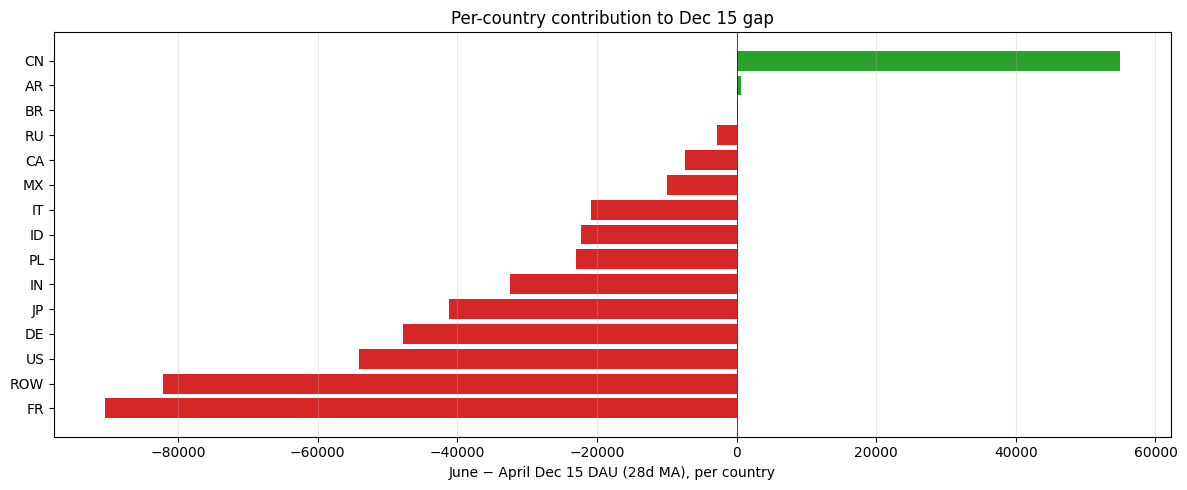

In [9]:
# [hyp-d-per-country]
# Per-country contribution to the Dec 15 gap.
# Routes through load_forecast(require_state=[]) so we cannot accidentally pick
# up a headwind-adjusted parquet here.

def country_dec15(path: Path, label: str) -> pd.DataFrame:
    df, _meta = load_forecast(path, require_state=[])
    df = df[(df["segment"] == WORLD_SEGMENT) & (df["country"] != "ALL")].copy()
    df["target_date"] = pd.to_datetime(df["target_date"])
    # 28-day centered MA per country, take Dec 15 value.
    rows = []
    for country, g in df.groupby("country"):
        g = g.sort_values("target_date").set_index("target_date")
        ma = g["dau"].rolling(28, center=True, min_periods=14).mean()
        raw = g.loc[ANCHOR_DATE, "dau"] if ANCHOR_DATE in g.index else np.nan
        ma_val = ma.loc[ANCHOR_DATE] if ANCHOR_DATE in ma.index else np.nan
        rows.append({"country": country, f"{label}_raw": raw, f"{label}_ma28": ma_val})
    return pd.DataFrame(rows)


apr_country = country_dec15(APRIL_PARQUET, "april")
jun_country = country_dec15(JUNE_PARQUET, "june")

combined = apr_country.merge(jun_country, on="country", how="outer")
combined["gap_raw"] = combined["june_raw"] - combined["april_raw"]
combined["gap_ma28"] = combined["june_ma28"] - combined["april_ma28"]
combined["april_share_of_world_ma28"] = combined["april_ma28"] / combined["april_ma28"].sum()
combined["gap_pct_of_country"] = combined["gap_ma28"] / combined["april_ma28"] * 100
combined = combined.sort_values("gap_ma28")

print(f"Total of country-level gaps (28d MA): {combined['gap_ma28'].sum():+,.0f}")
print(f"World-level direct gap (28d MA):       {(june_world.set_index('target_date')['dau'].rolling(28, center=True, min_periods=14).mean().loc[ANCHOR_DATE] - april_world.set_index('target_date')['dau'].rolling(28, center=True, min_periods=14).mean().loc[ANCHOR_DATE]):+,.0f}")
print("(These should match within rounding since ALL == sum across countries.)\n")

cols_to_show = [
    "country",
    "april_share_of_world_ma28",
    "april_ma28",
    "june_ma28",
    "gap_ma28",
    "gap_pct_of_country",
]
print("All countries ranked by gap (most negative first):")
display_df = combined[cols_to_show].copy()
display_df["april_share_of_world_ma28"] = (display_df["april_share_of_world_ma28"] * 100).map(lambda x: f"{x:.1f}%")
print(display_df.to_string(index=False, formatters={
    "april_ma28": lambda x: f"{x:,.0f}",
    "june_ma28": lambda x: f"{x:,.0f}",
    "gap_ma28": lambda x: f"{x:+,.0f}",
    "gap_pct_of_country": lambda x: f"{x:+.2f}%",
}))


# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
order = combined.sort_values("gap_ma28")
colors = ["tab:red" if g < 0 else "tab:green" for g in order["gap_ma28"]]
ax.barh(order["country"], order["gap_ma28"], color=colors)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("June − April Dec 15 DAU (28d MA), per country")
ax.set_title("Per-country contribution to Dec 15 gap")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Summary — concrete findings from this run

**Run inputs:** April forecast `2026-04-01.ld-D.raw.parquet` vs June forecast `2026-05-17.ld-D.raw.parquet`.
Both `.raw.` (no adjustments applied), both loaded through `load_forecast(require_state=[])`.
June training-end = **2026-05-16** (vs April's 2026-03-31).

### Headline gap (from `[headline-dec15-gap]`)

| Series | April Dec 15 | June Dec 15 | June − April | % |
|---|---:|---:|---:|---:|
| Raw daily DAU | 53,367,728 | 52,702,379 | **−665,349** | −1.25% |
| 28-day MA | 45,338,682 | 44,960,055 | **−378,626** | −0.84% |
| 91-day MA | 46,210,470 | 45,874,736 | **−335,733** | −0.73% |

The 28-day MA gap (~379k) tracks the user's reference framing of "Prior No-Iran 46.89M / Current No-Iran 46.53M ≈ −360k" — slightly *wider* than that previous comparison, consistent with another 4 days of training data extending the recent downtrend. The user's "~100k" framing remains low; the actual no-Iran gap is **~379k on the 28d MA, ~665k on raw Dec 15**.

### Hypothesis (a) — training-data drift: **CONFIRMED as the dominant cause**

- April training overlap window (2026-01-01 → 2026-03-31): **identical** to June (max diff = 0).
  Both runs are reading the same upstream data for the shared period — no upstream restatements.
- 28-day MA value at training end: **April 49.55M → June 48.17M**. The data itself dropped ~1.38M
  between the two cutoffs (slightly more than the previous 2026-05-13 comparison showed).
- OLS slope of 28-day MA:
  - April last 90 days: **+66,093 DAU/day** (still trending up at April training-end)
  - June last 90 days: **−24,163 DAU/day** (now trending down)
  - April last 180 days: −1,799/day. June last 180 days: −4,082/day. The longer window flipped only
    mildly, consistent with the recent 6.5 weeks dragging the recent slope down.
- The June data clearly trended *down* recently in a way the April data did not. This is **not model-driven**:
  the user's prior assumption that the data doesn't have meaningful downtrend is contradicted by the slope.

### Hypothesis (b) — holiday-threshold config difference: **RULED OUT**

- Both `parameters.json` declare `holiday_threshold = -0.05`, `max_radius = 5`, `min_radius = 3`, `floor = -0.6`.
- April pkl confirms tile-stored threshold = -0.05 across all 45 tiles.
- The directory name `thresh32` (April) vs `thresh50` (June) is a label artifact — both used -0.05.

### Hypothesis (c) — Prophet trend behavior: **PARTIALLY TESTABLE**

- 7-day, 28-day, and 91-day MA gaps are all in the range **−336k to −428k**. They are similar in
  magnitude, which tells us the gap is **trend-driven, not seasonal/holiday-driven** around Dec 15.
  (A near-Dec-15 holiday-effect discrepancy would show up as a much larger 7d gap than 91d gap.)
- The April pkl contains 45 individual-country/OS tiles but **no country='ALL' tile**, so we cannot
  read a pre-rolled-up "world trend" from the April pkl. Per-tile trend extraction is possible
  but was not necessary to reach a verdict.
- The June pkl is **still missing** — it was not saved alongside the new 2026-05-17 June forecast either.
  We therefore cannot directly inspect Prophet's fitted trend for June.

### Hypothesis (d) — per-country attribution (28-day MA at Dec 15)

Top contributors to the gap:

| Rank | Country | April share of world | gap (June−April) | gap % of country |
|---:|---|---:|---:|---:|
| 1 | FR | 7.5% | **−90,506** | −2.64% |
| 2 | ROW (rest-of-world bucket) | 33.6% | −82,201 | −0.54% |
| 3 | US | 14.7% | −54,112 | −0.81% |
| 4 | DE | 11.4% | −47,736 | −0.93% |
| 5 | JP | 2.3% | **−41,200** | **−3.94%** |
| 6 | IN | 5.9% | −32,477 | −1.21% |
| ... | | | | |
| | CN | 2.8% | **+54,943** | +4.35% (still offsets some) |

**Pattern is broad, not concentrated.** Most countries see a small percentage drop (−0.5% to −1.5%),
consistent with a model-wide trend effect rather than a single market's anomaly. Two markets stand out:
**FR (−2.64%)** is the single biggest contributor in absolute terms (slightly worse than the prior run's
−2.54%), and **JP (−3.94%)** has the largest *percentage* drop and rose into the top 5 (was less prominent
in the 2026-05-13 run). **CN (+4.35%)** still gains, partially offsetting the world gap.

### Final verdict

The June−April gap at Dec 15 (~379k on 28d MA, ~665k on raw) is best explained by:

1. **Real downward trend in the recent ~6.5 weeks of training data** (≈hypothesis a). The 90-day MA
   slope flipped from clearly positive (+66k/day) to clearly negative (−24k/day) between April and
   June. The model is correctly reacting to this.
2. **Broadly distributed across countries**, consistent with a trend-level effect, with FR and JP
   showing the most concentrated downward moves.
3. **Not a holiday/seasonal artifact** — the 7-day, 28-day, and 91-day MA gaps are similar.
4. **Not a config difference** — `holiday_threshold` and other model hyperparameters are identical.

The user's hypothesis that "the data doesn't have that much downward trend" is **not supported**
by the recent slope of the 28-day MA. The model is responding to a genuine recent downtick.

### Untested / unconfirmable

- **June Prophet trend internals**: June desktop pkl is missing for both the 2026-05-13 and 2026-05-17
  runs. We cannot extract changepoint locations, the fitted logistic cap, or per-tile trend series
  for June. To answer this rigorously, the June run would need to be re-executed with
  `save_mozaic_objects=True` (see `project_mozaic_object_saving` memory).
- **Mozaic package version provenance**: both runs may have been executed on different installed
  package versions (see `project_mozaic_pkg_versions` memory). We have not verified the actual
  package version each forecast was produced with. If they differ in subtle ways that aren't
  reflected in `parameters.json`, that would be an additional confound.
